<a href="https://colab.research.google.com/github/SammyBoi242006/CCPS_project/blob/main/models/final_model_V2.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted!")

!pip install albumentations timm -q
print("Done!")

Mounted at /content/drive
Done!


In [2]:
import os
import json
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import torch.nn.functional as F



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


In [3]:
PLANTVILLAGE  = '/content/drive/MyDrive/project/data/plantvillage_tomato/PlantVillage'
AUG_DATA_DIR  = '/content/drive/MyDrive/project/data/augmented_offline'
RESULTS       = '/content/drive/MyDrive/project/results'
MODELS        = '/content/drive/MyDrive/project/models'
os.makedirs(RESULTS,      exist_ok=True)
os.makedirs(MODELS,       exist_ok=True)
os.makedirs(AUG_DATA_DIR, exist_ok=True)

SELECTED_CLASSES = [
    'Tomato_healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato__Tomato_YellowLeaf__Curl_Virus'
]

CONFIG = {
    'image_size'   : 224,
    'batch_size'   : 32,
    'num_workers'  : 2,
    'epochs'       : 40,
    'lr'           : 1e-4,
    'seed'         : 42,
    'num_classes'  : 5,
    'mean'         : [0.485, 0.456, 0.406],
    'std'          : [0.229, 0.224, 0.225],
    'samples_per_class' : 1000,   # undersample to this
    'aug_multiplier'    : 4,      # 4 augmented copies per train image
}

class_to_idx = {cls: idx for idx, cls in enumerate(SELECTED_CLASSES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
short_names  = ['Healthy', 'Bacterial Spot', 'Early Blight',
                'Late Blight', 'Yellow Leaf Curl']

print("Classes:")
for cls, idx in class_to_idx.items():
    print(f"  {idx}: {cls}")

Classes:
  0: Tomato_healthy
  1: Tomato_Bacterial_spot
  2: Tomato_Early_blight
  3: Tomato_Late_blight
  4: Tomato__Tomato_YellowLeaf__Curl_Virus


In [4]:
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

# ── Step 1: Collect all paths per class ──────────────────────────────────────
all_paths, all_labels = [], []

for cls in SELECTED_CLASSES:
    cls_path = os.path.join(PLANTVILLAGE, cls)
    imgs = [
        os.path.join(cls_path, f) for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    # Undersample to 1000
    if len(imgs) > CONFIG['samples_per_class']:
        rng  = np.random.default_rng(CONFIG['seed'])
        imgs = list(rng.choice(imgs, CONFIG['samples_per_class'], replace=False))
    all_paths.extend(imgs)
    all_labels.extend([class_to_idx[cls]] * len(imgs))

print(f"Total after undersampling: {len(all_paths)}")
for idx, name in enumerate(short_names):
    print(f"  {name}: {all_labels.count(idx)}")

# ── Step 2: Split 80% (train+val) / 20% test ─────────────────────────────────
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.20,
    stratify=all_labels,
    random_state=CONFIG['seed']
)

# ── Step 3: Split 80% into 75% train / 25% val = 60% train / 20% val overall ─
train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels,
    test_size=0.25,               # 25% of 80% = 20% of total
    stratify=trainval_labels,
    random_state=CONFIG['seed']
)

print(f"\nTrain : {len(train_paths)} (~60%)")
print(f"Val   : {len(val_paths)}   (~20%)")
print(f"Test  : {len(test_paths)}  (~20%)")
print("\nPer class in train:")
for idx, name in enumerate(short_names):
    print(f"  {name}: {train_labels.count(idx)}")

Total after undersampling: 5000
  Healthy: 1000
  Bacterial Spot: 1000
  Early Blight: 1000
  Late Blight: 1000
  Yellow Leaf Curl: 1000

Train : 3000 (~60%)
Val   : 1000   (~20%)
Test  : 1000  (~20%)

Per class in train:
  Healthy: 600
  Bacterial Spot: 600
  Early Blight: 600
  Late Blight: 600
  Yellow Leaf Curl: 600


In [ ]:
aug_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.5),
    A.RandomResizedCrop(
        size=(CONFIG['image_size'], CONFIG['image_size']),
        scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5
    ),
    A.ColorJitter(brightness=0.3, contrast=0.3,
                  saturation=0.2, hue=0.1, p=0.5),
    A.RandomShadow(p=0.3),
    A.CoarseDropout(num_holes_range=(1, 8),
                    hole_height_range=(10, 20),
                    hole_width_range=(10, 20), p=0.3),
    A.GaussNoise(std_range=(0.02, 0.1), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.GaussianBlur(blur_limit=3, p=0.2),
])

resize_only = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
])

def save_image(img_array, save_path):
    Image.fromarray(img_array).save(save_path)

# ── Augment and save train images ─────────────────────────────────────────────
aug_train_paths, aug_train_labels = [], []

print("Starting offline augmentation for train set...")
for i, (path, label) in enumerate(zip(train_paths, train_labels)):
    img        = np.array(Image.open(path).convert('RGB'))
    cls_name   = idx_to_class[label]
    cls_dir    = os.path.join(AUG_DATA_DIR, 'train', cls_name)
    os.makedirs(cls_dir, exist_ok=True)

    # Save original (resized)
    orig_resized  = resize_only(image=img)['image']
    orig_filename = f"orig_{i:05d}.jpg"
    orig_savepath = os.path.join(cls_dir, orig_filename)
    save_image(orig_resized, orig_savepath)
    aug_train_paths.append(orig_savepath)
    aug_train_labels.append(label)

    # Save N augmented copies
    for n in range(CONFIG['aug_multiplier']):
        aug_img      = aug_transform(image=img)['image']
        aug_filename = f"aug_{i:05d}_v{n}.jpg"
        aug_savepath = os.path.join(cls_dir, aug_filename)
        save_image(aug_img, aug_savepath)
        aug_train_paths.append(aug_savepath)
        aug_train_labels.append(label)

    if (i + 1) % 200 == 0:
        print(f"  Processed {i+1}/{len(train_paths)} images...")

print(f"\nAugmentation complete!")
print(f"Total train images (orig + aug): {len(aug_train_paths)}")
print(f"Per class:")
for idx, name in enumerate(short_names):
    print(f"  {name}: {aug_train_labels.count(idx)}")

Starting offline augmentation for train set...
  Processed 200/3000 images...
  Processed 400/3000 images...
  Processed 600/3000 images...
  Processed 800/3000 images...
  Processed 1000/3000 images...
  Processed 1200/3000 images...
  Processed 1400/3000 images...
  Processed 1600/3000 images...
  Processed 1800/3000 images...
  Processed 2000/3000 images...
  Processed 2200/3000 images...
  Processed 2400/3000 images...
  Processed 2600/3000 images...
  Processed 2800/3000 images...
  Processed 3000/3000 images...

Augmentation complete!
Total train images (orig + aug): 15000
Per class:
  Healthy: 3000
  Bacterial Spot: 3000
  Early Blight: 3000
  Late Blight: 3000
  Yellow Leaf Curl: 3000


In [5]:
# Cell 5 — Load augmented images from Drive (no re-augmentation)

aug_train_paths, aug_train_labels = [], []

AUG_DATA_DIR  = '/content/drive/MyDrive/project/data/augmented_offline'
AUG_TRAIN_DIR = os.path.join(AUG_DATA_DIR, 'train')

print("Loading augmented images from Drive...")

for cls in SELECTED_CLASSES:
    label   = class_to_idx[cls]
    cls_dir = os.path.join(AUG_TRAIN_DIR, cls)

    if not os.path.exists(cls_dir):
        print(f"WARNING: folder not found — {cls_dir}")
        continue

    for img_file in sorted(os.listdir(cls_dir)):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            aug_train_paths.append(os.path.join(cls_dir, img_file))
            aug_train_labels.append(label)

print(f"\nTotal augmented train images loaded : {len(aug_train_paths)}")
print(f"Per class:")
for idx, name in enumerate(short_names):
    count = aug_train_labels.count(idx)
    print(f"  {name}: {count}")

Loading augmented images from Drive...

Total augmented train images loaded : 15000
Per class:
  Healthy: 3000
  Bacterial Spot: 3000
  Early Blight: 3000
  Late Blight: 3000
  Yellow Leaf Curl: 3000


In [6]:
# Normalize only — augmentation already done offline
train_transform = A.Compose([
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

class TomatoDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = np.array(Image.open(self.paths[idx]).convert('RGB'))
        label = self.labels[idx]
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

# Train uses augmented paths, val/test use original paths
train_dataset = TomatoDataset(aug_train_paths,  aug_train_labels, train_transform)
val_dataset   = TomatoDataset(val_paths,         val_labels,       val_test_transform)
test_dataset  = TomatoDataset(test_paths,         test_labels,      val_test_transform)

print(f"Train dataset : {len(train_dataset)}")
print(f"Val dataset   : {len(val_dataset)}")
print(f"Test dataset  : {len(test_dataset)}")

Train dataset : 15000
Val dataset   : 1000
Test dataset  : 1000


In [7]:
# Simple uniform sampler — all classes already equal after undersampling
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True,   num_workers=CONFIG['num_workers'],
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                          shuffle=False,  num_workers=CONFIG['num_workers'],
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                          shuffle=False,  num_workers=CONFIG['num_workers'],
                          pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 469
Val batches   : 32
Test batches  : 32


In [8]:
class MultiScaleStem(nn.Module):
    """
    Novelty 1 — Three parallel kernels capture disease
    features at multiple physical scales simultaneously.
    """
    def __init__(self):
        super().__init__()
        self.branch_3x3 = nn.Sequential(
            nn.Conv2d(3, 21, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(21), nn.ReLU()
        )
        self.branch_5x5 = nn.Sequential(
            nn.Conv2d(3, 21, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(21), nn.ReLU()
        )
        self.branch_7x7 = nn.Sequential(
            nn.Conv2d(3, 22, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm2d(22), nn.ReLU()
        )
        self.compress = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU()
        )

    def forward(self, x):
        b3  = self.branch_3x3(x)
        b5  = self.branch_5x5(x)
        b7  = self.branch_7x7(x)
        out = torch.cat([b3, b5, b7], dim=1)
        return self.compress(out)

print("MultiScaleStem defined.")

MultiScaleStem defined.


In [9]:
class SEModule(nn.Module):
    """
    Novelty 2 — Channel attention learns which channels
    represent true disease signal vs noise.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.se(x).view(x.size(0), x.size(1), 1, 1)
        return x * w


class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, use_se=False):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride,
                      padding=1, groups=in_ch, bias=False),
            nn.GroupNorm(num_groups=min(32, in_ch), num_channels=in_ch),
            nn.ReLU()
        )
        self.pw = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.GroupNorm(num_groups=min(32, out_ch), num_channels=out_ch),
            nn.ReLU()
        )
        self.se      = SEModule(out_ch) if use_se else nn.Identity()
        self.dropout = nn.Dropout2d(0.1)

    def forward(self, x):
        x = self.dw(x)
        x = self.pw(x)
        x = self.se(x)
        return self.dropout(x)

print("SEModule and DepthwiseSeparableBlock defined.")

SEModule and DepthwiseSeparableBlock defined.


In [10]:
class CNNBranch(nn.Module):
    """
    Custom CNN with:
    - Multi-Scale Stem (Novelty 1)
    - SE Module (Novelty 2)
    - GeM Pooling (Novelty 4) replacing standard GAP
    """
    def __init__(self):
        super().__init__()
        self.stem   = MultiScaleStem()
        self.block1 = DepthwiseSeparableBlock(64,  128, use_se=False)
        self.block2 = DepthwiseSeparableBlock(128, 256, use_se=True)
        self.block3 = DepthwiseSeparableBlock(256, 512, use_se=False)

        # Novelty 4 — GeM pooling, learned exponent initialized at 3.0
        self.gem_p  = nn.Parameter(torch.ones(1) * 3.0)
        self.flat   = nn.Flatten()

    def gem_pool(self, x):
        # Clamp prevents numerical issues with near-zero values
        x = x.clamp(min=1e-6).pow(self.gem_p)
        x = x.mean(dim=[2, 3])
        return x.pow(1.0 / self.gem_p)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gem_pool(x)     # GeM instead of GAP
        return self.flat(x)      # 512-dim vector

print("CNNBranch with GeM defined.")

CNNBranch with GeM defined.


In [11]:
class CAFormerBranch(nn.Module):
    """
    Pretrained CAFormer-s18 with selective freezing.
    Stages 1-2 frozen, Stage 3 partial, Stage 4 full.
    """
    def __init__(self):
        super().__init__()
        self.caformer = timm.create_model(
            'caformer_s18', pretrained=True, num_classes=0
        )

        # Freeze everything first
        for param in self.caformer.parameters():
            param.requires_grad = False

        # Unfreeze Stage 4 fully
        for param in self.caformer.stages[3].parameters():
            param.requires_grad = True

        # Unfreeze last 2 blocks of Stage 3
        stage3_blocks = list(self.caformer.stages[2].blocks)
        for block in stage3_blocks[-2:]:
            for param in block.parameters():
                param.requires_grad = True

        # Unfreeze head if exists
        if hasattr(self.caformer, 'head'):
            for param in self.caformer.head.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.caformer(x)   # 512-dim vector

print("CAFormerBranch defined.")

CAFormerBranch defined.


In [12]:
class CBSEF(nn.Module):
    """
    Novelty 3 — Cross-Branch SE Fusion.
    Learns to dynamically weight CNN vs CAFormer
    features per disease class.
    """
    def __init__(self, feature_dim=1024, reduction=16):
        super().__init__()
        self.se_gate = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(feature_dim // reduction, feature_dim, bias=False),
            nn.Sigmoid()
        )

    def forward(self, cnn_feat, trans_feat):
        combined = torch.cat([cnn_feat, trans_feat], dim=1)
        gate     = self.se_gate(combined)
        gated    = combined * gate
        return gated + combined   # residual connection

print("CBSEF defined.")

CBSEF defined.


In [13]:
class FullHybridModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.cnn_branch   = CNNBranch()
        self.trans_branch = CAFormerBranch()
        self.fusion       = CBSEF(feature_dim=1024, reduction=16)
        self.classifier   = nn.Sequential(
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        cnn_feat   = self.cnn_branch(x)
        trans_feat = self.trans_branch(x)
        fused      = self.fusion(cnn_feat, trans_feat)
        return self.classifier(fused)

model = FullHybridModel(num_classes=CONFIG['num_classes']).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Learned GeM p init  : {model.cnn_branch.gem_p.item():.4f}")

model.safetensors:   0%|          | 0.00/105M [00:00<?, ?B/s]

Total parameters    : 23,829,878
Trainable parameters: 13,971,856
Learned GeM p init  : 3.0000


In [ ]:
# All classes equal after undersampling — uniform weights
counts    = [aug_train_labels.count(i) for i in range(CONFIG['num_classes'])]
weights   = torch.tensor([1.0/c for c in counts], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam([
    {'params': model.cnn_branch.parameters(),                              'lr': CONFIG['lr']},
    {'params': model.fusion.parameters(),                                  'lr': CONFIG['lr']},
    {'params': model.classifier.parameters(),                              'lr': CONFIG['lr']},
    {'params': filter(lambda p: p.requires_grad,
               model.trans_branch.parameters()),                           'lr': CONFIG['lr'] * 0.1},
], lr=CONFIG['lr'])

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-6
)

print("Loss, optimizer, scheduler ready.")
print(f"Class counts in train: {counts}")

Loss, optimizer, scheduler ready.
Class counts in train: [3000, 3000, 3000, 3000, 3000]


In [ ]:
train_losses, val_losses       = [], []
train_accuracies, val_accuracies = [], []
best_val_acc = 0.0

for epoch in range(CONFIG['epochs']):
    # Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds        = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_acc      = correct / total * 100
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs   = model(images)
            val_loss += criterion(outputs, labels).item()
            preds     = outputs.argmax(dim=1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = correct / total * 100
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'             : val_acc,
            'class_to_idx'        : class_to_idx,
            'config'              : CONFIG,
        }, os.path.join(MODELS, 'best_hybrid_v2.pth'))
    print(
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Best: {best_val_acc:.2f}%")

gem_p_final = model.cnn_branch.gem_p.item()
print(f"\nTraining complete. Best Val Acc : {best_val_acc:.2f}%")
print(f"Final learned GeM p value      : {gem_p_final:.4f}")

Train Loss: 0.1562 | Train Acc: 95.65% | Val Loss: 0.0766 | Val Acc: 98.00% | Best: 98.00%
Train Loss: 0.0756 | Train Acc: 97.94% | Val Loss: 0.0453 | Val Acc: 98.90% | Best: 98.90%
Train Loss: 0.0450 | Train Acc: 98.75% | Val Loss: 0.0462 | Val Acc: 98.60% | Best: 98.90%
Train Loss: 0.0249 | Train Acc: 99.42% | Val Loss: 0.0384 | Val Acc: 99.00% | Best: 99.00%
Train Loss: 0.0169 | Train Acc: 99.63% | Val Loss: 0.0417 | Val Acc: 99.00% | Best: 99.00%
Train Loss: 0.0106 | Train Acc: 99.81% | Val Loss: 0.0397 | Val Acc: 99.10% | Best: 99.10%
Train Loss: 0.0076 | Train Acc: 99.87% | Val Loss: 0.0447 | Val Acc: 98.90% | Best: 99.10%
Train Loss: 0.0051 | Train Acc: 99.93% | Val Loss: 0.0376 | Val Acc: 99.10% | Best: 99.10%
Train Loss: 0.0044 | Train Acc: 99.93% | Val Loss: 0.0397 | Val Acc: 98.90% | Best: 99.10%
Train Loss: 0.0038 | Train Acc: 99.93% | Val Loss: 0.0479 | Val Acc: 98.70% | Best: 99.10%
Train Loss: 0.0018 | Train Acc: 100.00% | Val Loss: 0.0437 | Val Acc: 98.80% | Best: 99.10

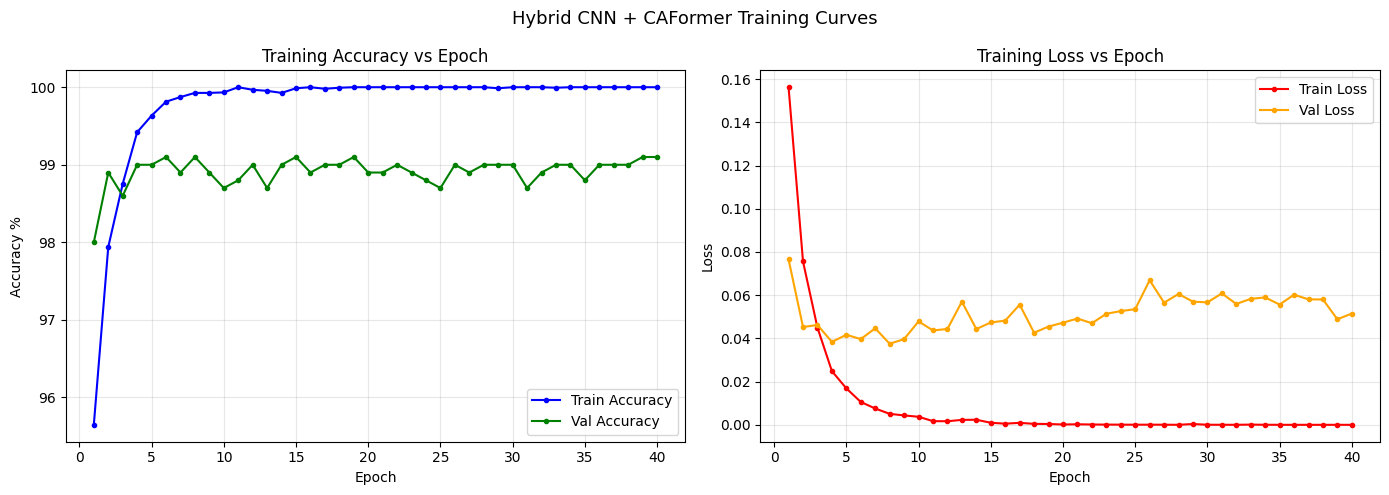

Saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Training Accuracy vs Epoch
axes[0].plot(range(1, CONFIG['epochs']+1), train_accuracies,
             label='Train Accuracy', marker='o', markersize=3, color='blue')
axes[0].plot(range(1, CONFIG['epochs']+1), val_accuracies,
             label='Val Accuracy', marker='o', markersize=3, color='green')
axes[0].set_title('Training Accuracy vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy %')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Training Loss vs Epoch
axes[1].plot(range(1, CONFIG['epochs']+1), train_losses,
             label='Train Loss', marker='o', markersize=3, color='red')
axes[1].plot(range(1, CONFIG['epochs']+1), val_losses,
             label='Val Loss', marker='o', markersize=3, color='orange')
axes[1].set_title('Training Loss vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Hybrid CNN + CAFormer Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'v2_training_curves.png'), dpi=150)
plt.show()
print("Saved!")

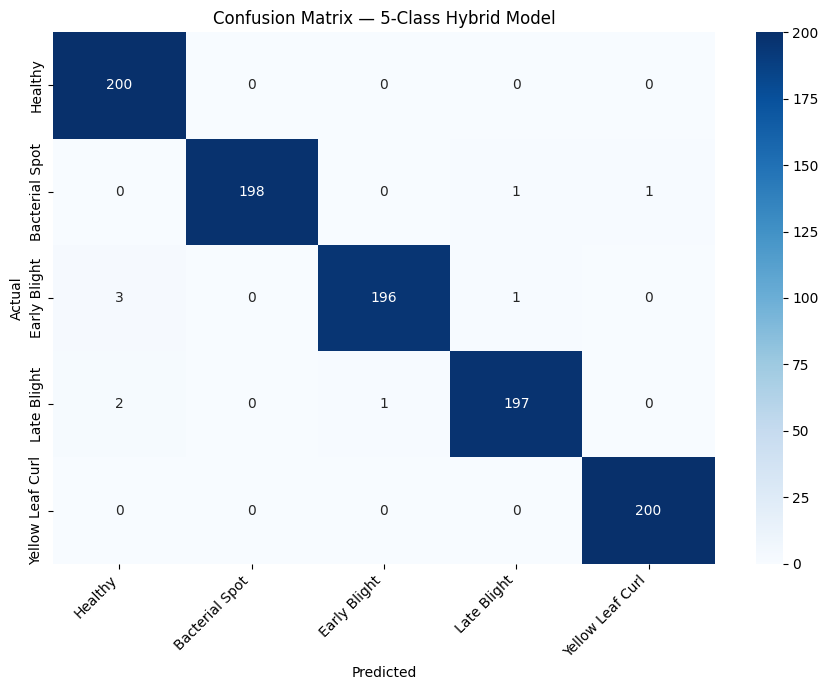


Classification Report:
                  precision    recall  f1-score   support

         Healthy       0.98      1.00      0.99       200
  Bacterial Spot       1.00      0.99      0.99       200
    Early Blight       0.99      0.98      0.99       200
     Late Blight       0.99      0.98      0.99       200
Yellow Leaf Curl       1.00      1.00      1.00       200

        accuracy                           0.99      1000
       macro avg       0.99      0.99      0.99      1000
    weighted avg       0.99      0.99      0.99      1000



In [ ]:
# Load best model
checkpoint = torch.load(os.path.join(MODELS, 'best_hybrid_v2.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels_list, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.title('Confusion Matrix — 5-Class Hybrid Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'v2_confusion_matrix.png'), dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels_list, all_preds, target_names=short_names))

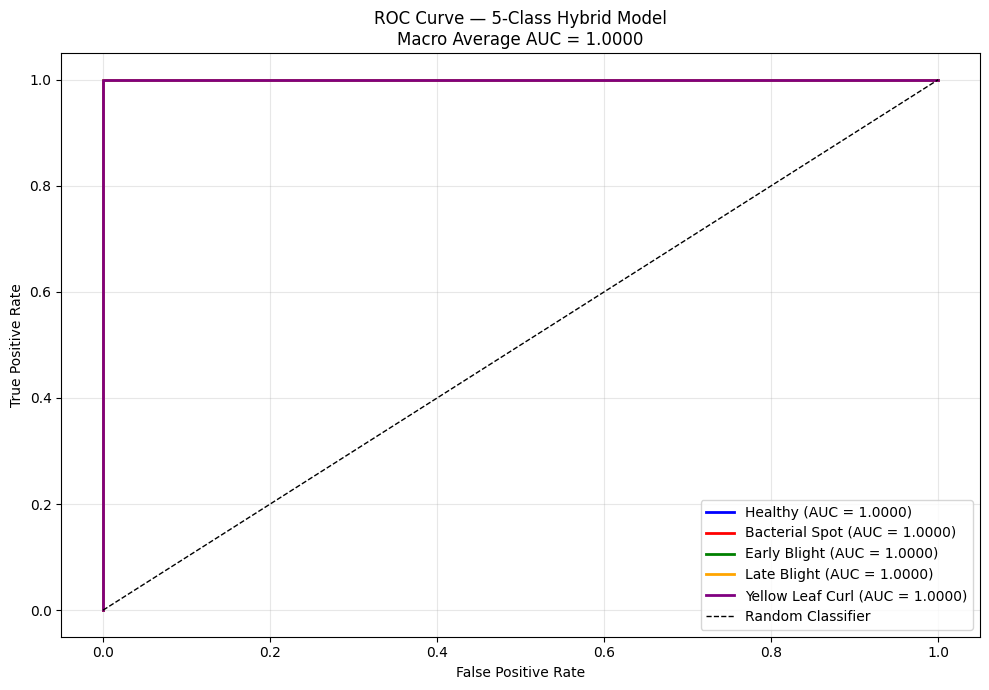


AUC Scores per class:
  Healthy             : 1.0000
  Bacterial Spot      : 1.0000
  Early Blight        : 1.0000
  Late Blight         : 1.0000
  Yellow Leaf Curl    : 1.0000

  Macro Average AUC   : 1.0000


In [ ]:
# Get probabilities for all test images
model.eval()
all_probs, all_labels_roc = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels_roc.extend(labels.numpy())

all_probs      = np.array(all_probs)
all_labels_roc = np.array(all_labels_roc)

# Binarize labels for one-vs-rest ROC
labels_bin = label_binarize(all_labels_roc, classes=list(range(CONFIG['num_classes'])))

# Compute ROC and AUC per class
plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange', 'purple']
auc_scores = {}

for i, (name, color) in enumerate(zip(short_names, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    auc_val     = auc(fpr, tpr)
    auc_scores[name] = auc_val
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc_val:.4f})')

# Macro average AUC
macro_auc = np.mean(list(auc_scores.values()))
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.title(f'ROC Curve — 5-Class Hybrid Model\nMacro Average AUC = {macro_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'v2_roc_curve.png'), dpi=150)
plt.show()

print("\nAUC Scores per class:")
for name, score in auc_scores.items():
    print(f"  {name:20s}: {score:.4f}")
print(f"\n  Macro Average AUC   : {macro_auc:.4f}")

In [ ]:
gem_p_final = model.cnn_branch.gem_p.item()

summary = {
    'best_val_accuracy' : best_val_acc,
    'total_params'      : total,
    'trainable_params'  : trainable,
    'gem_p_learned'     : gem_p_final,
    'macro_auc'         : macro_auc,
    'auc_per_class'     : auc_scores,
    'classes'           : SELECTED_CLASSES,
    'epochs_trained'    : CONFIG['epochs'],
}

with open(os.path.join(RESULTS, 'v2_results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("=" * 50)
print("FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"Best Val Accuracy  : {best_val_acc:.2f}%")
print(f"Macro Average AUC  : {macro_auc:.4f}")
print(f"Learned GeM p      : {gem_p_final:.4f}")
print(f"Total Params       : {total:,}")
print(f"Trainable Params   : {trainable:,}")
print("=" * 50)

if gem_p_final > 1.5:
    print(f"\nGeM Insight: p={gem_p_final:.2f} > 1 confirms the network")
    print("learned to emphasize high-activation lesion pixels")
    print("over uniform healthy tissue — validating GeM choice.")
else:
    print(f"\nGeM Insight: p={gem_p_final:.2f} ≈ 1 suggests GAP was")
    print("already near-optimal for this dataset.")

FINAL RESULTS SUMMARY
Best Val Accuracy  : 99.69%
Macro Average AUC  : 1.0000
Learned GeM p      : 2.9402
Total Params       : 983
Trainable Params   : 13,971,856

GeM Insight: p=2.94 > 1 confirms the network
learned to emphasize high-activation lesion pixels
over uniform healthy tissue — validating GeM choice.


In [ ]:
##FOR PLANTDOC DATASET#####========================================

In [ ]:
# Mapping from PlantDoc folder names to your 5 class indices
# Only tomato classes that match your selected 5 classes

PLANTDOC_TRAIN = '/content/drive/MyDrive/project/data/plantdoc_tomato/PlantDoc-Dataset-master/train'
PLANTDOC_TEST  = '/content/drive/MyDrive/project/data/plantdoc_tomato/PlantDoc-Dataset-master/test'

# PlantDoc name → your class index
PLANTDOC_MAPPING = {
    'Tomato leaf'                        : class_to_idx['Tomato_healthy'],
    'Tomato leaf bacterial spot'         : class_to_idx['Tomato_Bacterial_spot'],
    'Tomato Early blight leaf'           : class_to_idx['Tomato_Early_blight'],
    'Tomato leaf late blight'            : class_to_idx['Tomato_Late_blight'],
    'Tomato leaf yellow virus'           : class_to_idx['Tomato__Tomato_YellowLeaf__Curl_Virus'],
}

print("PlantDoc → Your class mapping:")
for plantdoc_name, idx in PLANTDOC_MAPPING.items():
    print(f"  '{plantdoc_name}' → {idx}: {idx_to_class[idx]}")

PlantDoc → Your class mapping:
  'Tomato leaf' → 0: Tomato_healthy
  'Tomato leaf bacterial spot' → 1: Tomato_Bacterial_spot
  'Tomato Early blight leaf' → 2: Tomato_Early_blight
  'Tomato leaf late blight' → 3: Tomato_Late_blight
  'Tomato leaf yellow virus' → 4: Tomato__Tomato_YellowLeaf__Curl_Virus


In [ ]:
def load_plantdoc_split(root, mapping):
    paths, labels = [], []
    for folder_name, label_idx in mapping.items():
        folder_path = os.path.join(root, folder_name)
        if not os.path.exists(folder_path):
            print(f"WARNING: folder not found — {folder_path}")
            continue
        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(folder_path, img_file))
                labels.append(label_idx)
    return paths, labels

# Load both splits
pd_train_paths, pd_train_labels = load_plantdoc_split(PLANTDOC_TRAIN, PLANTDOC_MAPPING)
pd_test_paths,  pd_test_labels  = load_plantdoc_split(PLANTDOC_TEST,  PLANTDOC_MAPPING)

# Combine train + test for full PlantDoc evaluation
pd_all_paths  = pd_train_paths + pd_test_paths
pd_all_labels = pd_train_labels + pd_test_labels

print(f"PlantDoc Train images : {len(pd_train_paths)}")
print(f"PlantDoc Test images  : {len(pd_test_paths)}")
print(f"PlantDoc Total        : {len(pd_all_paths)}")
print("\nClass breakdown:")
for idx, name in enumerate(short_names):
    count = pd_all_labels.count(idx)
    print(f"  {name:25s}: {count}")

PlantDoc Train images : 406
PlantDoc Test images  : 42
PlantDoc Total        : 448

Class breakdown:
  Healthy                  : 63
  Bacterial Spot           : 110
  Early Blight             : 88
  Late Blight              : 111
  Yellow Leaf Curl         : 76


In [ ]:
# No augmentation on PlantDoc — preprocessing only
# PlantDoc already has real-world conditions built in

plantdoc_dataset = TomatoDataset(pd_all_paths, pd_all_labels, val_test_transform)

plantdoc_loader  = DataLoader(
    plantdoc_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"PlantDoc batches: {len(plantdoc_loader)}")
print(f"PlantDoc total  : {len(plantdoc_dataset)}")

PlantDoc batches: 14
PlantDoc total  : 448


In [ ]:
# Load best saved model
checkpoint = torch.load(os.path.join(MODELS, 'best_hybrid_v2.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

pd_preds, pd_labels_list, pd_probs = [], [], []

with torch.no_grad():
    for images, labels in plantdoc_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(dim=1).cpu().numpy()
        pd_preds.extend(preds)
        pd_labels_list.extend(labels.numpy())
        pd_probs.extend(probs)

pd_probs       = np.array(pd_probs)
pd_labels_list = np.array(pd_labels_list)
pd_preds       = np.array(pd_preds)

# Overall accuracy
pd_accuracy = (pd_preds == pd_labels_list).mean() * 100
print(f"PlantDoc Overall Accuracy: {pd_accuracy:.2f}%")

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b5889fc540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x78b5889fc540>assert self._parent_pid == os.getpid(), 'can only test a child process'

Traceback (most recent call last):

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
       self._shutdown_workers()    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
      if w.is_alive():  
  ^ ^ ^ ^ ^ ^ ^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

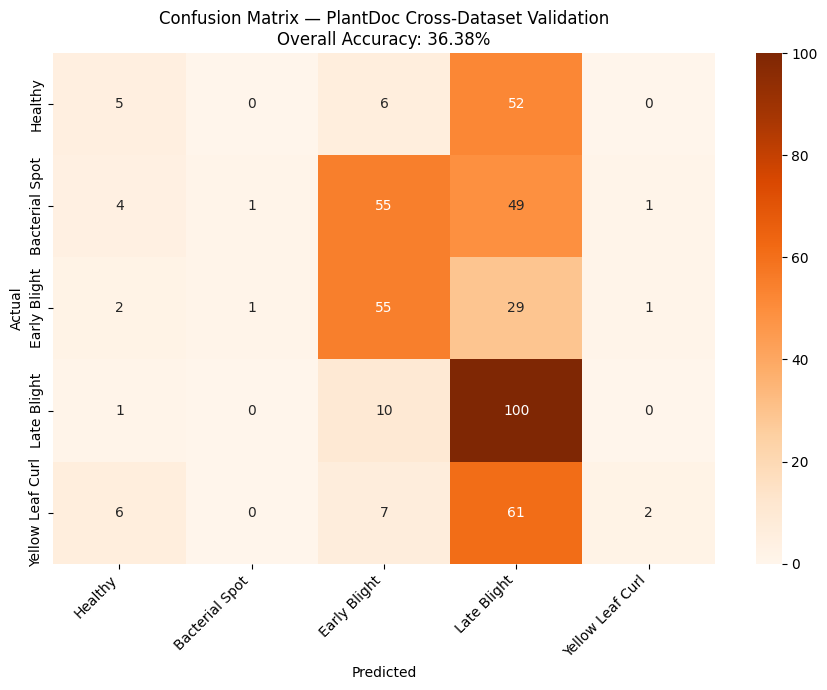


PlantDoc Classification Report:
                  precision    recall  f1-score   support

         Healthy       0.28      0.08      0.12        63
  Bacterial Spot       0.50      0.01      0.02       110
    Early Blight       0.41      0.62      0.50        88
     Late Blight       0.34      0.90      0.50       111
Yellow Leaf Curl       0.50      0.03      0.05        76

        accuracy                           0.36       448
       macro avg       0.41      0.33      0.24       448
    weighted avg       0.41      0.36      0.25       448



In [ ]:
cm_pd = confusion_matrix(pd_labels_list, pd_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_pd, annot=True, fmt='d', cmap='Oranges',
            xticklabels=short_names, yticklabels=short_names)
plt.title(f'Confusion Matrix — PlantDoc Cross-Dataset Validation\nOverall Accuracy: {pd_accuracy:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'plantdoc_confusion_matrix.png'), dpi=150)
plt.show()

print("\nPlantDoc Classification Report:")
print(classification_report(pd_labels_list, pd_preds, target_names=short_names))

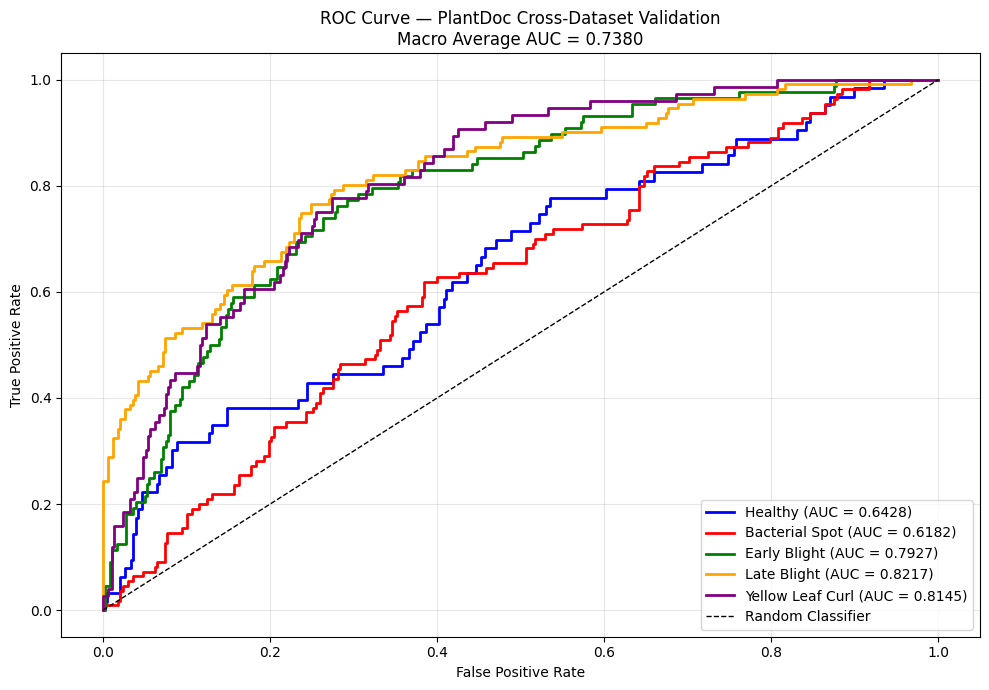


PlantDoc AUC per class:
  Healthy                  : 0.6428
  Bacterial Spot           : 0.6182
  Early Blight             : 0.7927
  Late Blight              : 0.8217
  Yellow Leaf Curl         : 0.8145

  Macro Average AUC     : 0.7380


In [ ]:
# Binarize for ROC
pd_labels_bin = label_binarize(pd_labels_list, classes=list(range(CONFIG['num_classes'])))

plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange', 'purple']
pd_auc_scores = {}

for i, (name, color) in enumerate(zip(short_names, colors)):
    fpr, tpr, _ = roc_curve(pd_labels_bin[:, i], pd_probs[:, i])
    auc_val      = auc(fpr, tpr)
    pd_auc_scores[name] = auc_val
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc_val:.4f})')

pd_macro_auc = np.mean(list(pd_auc_scores.values()))
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.title(f'ROC Curve — PlantDoc Cross-Dataset Validation\nMacro Average AUC = {pd_macro_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'plantdoc_roc_curve.png'), dpi=150)
plt.show()

print("\nPlantDoc AUC per class:")
for name, score in pd_auc_scores.items():
    print(f"  {name:25s}: {score:.4f}")
print(f"\n  Macro Average AUC     : {pd_macro_auc:.4f}")

In [ ]:
print("PlantDoc class breakdown:")
for idx, name in enumerate(short_names):
    count = list(pd_labels_list).count(idx)
    print(f"  {name}: {count}")

PlantDoc class breakdown:


NameError: name 'pd_labels_list' is not defined

In [ ]:
# Load PlantDoc train and test separately this time
pd_train_paths, pd_train_labels = load_plantdoc_split(PLANTDOC_TRAIN, PLANTDOC_MAPPING)
pd_test_paths,  pd_test_labels  = load_plantdoc_split(PLANTDOC_TEST,  PLANTDOC_MAPPING)

print(f"PlantDoc Train : {len(pd_train_paths)} images")
print(f"PlantDoc Test  : {len(pd_test_paths)} images")

print("\nTrain class breakdown:")
for idx, name in enumerate(short_names):
    count = pd_train_labels.count(idx)
    print(f"  {name}: {count}")

print("\nTest class breakdown:")
for idx, name in enumerate(short_names):
    count = pd_test_labels.count(idx)
    print(f"  {name}: {count}")

NameError: name 'load_plantdoc_split' is not defined

In [ ]:
# Slightly stronger augmentation for PlantDoc fine-tuning
# PlantDoc images are already real-world so we add more variation
plantdoc_train_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.RandomResizedCrop(
        size=(CONFIG['image_size'], CONFIG['image_size']),
        scale=(0.7, 1.0), ratio=(0.9, 1.1), p=0.5
    ),
    A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1, p=0.5),
    A.RandomShadow(p=0.4),
    A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.3),
    A.GaussianBlur(blur_limit=3, p=0.3),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

print("PlantDoc fine-tune transforms ready.")

PlantDoc fine-tune transforms ready.


/tmp/ipykernel_2394/2766170830.py:14: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),
/tmp/ipykernel_2394/2766170830.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


In [ ]:
pd_train_dataset = TomatoDataset(pd_train_paths, pd_train_labels, plantdoc_train_transform)
pd_test_dataset  = TomatoDataset(pd_test_paths,  pd_test_labels,  val_test_transform)

# Weighted sampler for PlantDoc train — handles imbalance
pd_class_counts   = Counter(pd_train_labels)
pd_class_weights  = {cls: 1.0 / count for cls, count in pd_class_counts.items()
                     if count > 0}
pd_sample_weights = torch.tensor(
    [pd_class_weights.get(l, 0) for l in pd_train_labels], dtype=torch.float
)
pd_sampler = WeightedRandomSampler(pd_sample_weights, len(pd_sample_weights),
                                   replacement=True)

pd_train_loader = DataLoader(pd_train_dataset, batch_size=16,
                             sampler=pd_sampler, num_workers=2, pin_memory=True)
pd_test_loader  = DataLoader(pd_test_dataset,  batch_size=16,
                             shuffle=False, num_workers=2, pin_memory=True)

print(f"PlantDoc Train batches : {len(pd_train_loader)}")
print(f"PlantDoc Test batches  : {len(pd_test_loader)}")

PlantDoc Train batches : 26
PlantDoc Test batches  : 3


In [ ]:
# Load the best PlantVillage trained model
checkpoint = torch.load(
    os.path.join(MODELS, 'best_hybrid_v2.pth'),
    map_location=device
)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded base model — PlantVillage Val Acc: {checkpoint['val_acc']:.2f}%")

# Unfreeze EVERYTHING for PlantDoc fine-tuning
# Small dataset needs full model adaptation
for param in model.parameters():
    param.requires_grad = True

trainable_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"All params unfrozen: {trainable_ft:,}")

Loaded base model — PlantVillage Val Acc: 99.69%
All params unfrozen: 23,829,878


In [ ]:
# Lower lr for pretrained CAFormer, higher for CNN and fusion
ft_optimizer = optim.Adam([
    {'params': model.cnn_branch.parameters(),   'lr': 1e-5},
    {'params': model.fusion.parameters(),        'lr': 1e-5},
    {'params': model.classifier.parameters(),    'lr': 1e-5},
    {'params': model.trans_branch.parameters(),  'lr': 1e-6},
], lr=1e-5)

ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer, T_max=20, eta_min=1e-7
)

# Weighted loss
pd_counts    = [pd_class_counts.get(i, 1) for i in range(CONFIG['num_classes'])]
pd_weights   = torch.tensor([1.0/c for c in pd_counts], dtype=torch.float).to(device)
ft_criterion = nn.CrossEntropyLoss(weight=pd_weights)

# Smaller batch size — more updates per epoch on small dataset
pd_train_loader = DataLoader(pd_train_dataset, batch_size=8,
                             sampler=pd_sampler, num_workers=2, pin_memory=True)
pd_test_loader  = DataLoader(pd_test_dataset,  batch_size=8,
                             shuffle=False, num_workers=2, pin_memory=True)

ft_train_losses, ft_val_accuracies = [], []
best_ft_acc = 0.0
FT_EPOCHS   = 35

print(f"Fine-tuning for {FT_EPOCHS} epochs on PlantDoc train...")
print("=" * 60)

for epoch in range(FT_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in pd_train_loader:
        images, labels = images.to(device), labels.to(device)
        ft_optimizer.zero_grad()
        outputs = model(images)
        loss    = ft_criterion(outputs, labels)
        loss.backward()
        ft_optimizer.step()
        running_loss += loss.item()
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    avg_loss  = running_loss / len(pd_train_loader)
    train_acc = correct / total * 100
    ft_train_losses.append(avg_loss)

    # Evaluate on PlantDoc test
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in pd_test_loader:
            images, labels = images.to(device), labels.to(device)
            preds   = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    test_acc = correct / total * 100
    ft_val_accuracies.append(test_acc)

    if test_acc > best_ft_acc:
        best_ft_acc = test_acc
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'val_acc'          : test_acc,
            'class_to_idx'     : class_to_idx,
            'config'           : CONFIG,
        }, os.path.join(MODELS, 'best_hybrid_v2_plantdoc_finetuned.pth'))

    print(f"Epoch {epoch+1:02d}/{FT_EPOCHS} | "
          f"Train Loss: {avg_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"PlantDoc Test Acc: {test_acc:.2f}% | "
          f"Best: {best_ft_acc:.2f}%")

print(f"\nFine-tuning complete. Best PlantDoc Acc: {best_ft_acc:.2f}%")

Fine-tuning for 35 epochs on PlantDoc train...
Epoch 01/35 | Train Loss: 1.4716 | Train Acc: 57.39% | PlantDoc Test Acc: 61.90% | Best: 61.90%
Epoch 02/35 | Train Loss: 1.4427 | Train Acc: 57.64% | PlantDoc Test Acc: 64.29% | Best: 64.29%
Epoch 03/35 | Train Loss: 1.4163 | Train Acc: 54.43% | PlantDoc Test Acc: 66.67% | Best: 66.67%
Epoch 04/35 | Train Loss: 1.3720 | Train Acc: 54.93% | PlantDoc Test Acc: 66.67% | Best: 66.67%
Epoch 05/35 | Train Loss: 1.3798 | Train Acc: 53.20% | PlantDoc Test Acc: 64.29% | Best: 66.67%
Epoch 06/35 | Train Loss: 1.2229 | Train Acc: 59.85% | PlantDoc Test Acc: 64.29% | Best: 66.67%
Epoch 07/35 | Train Loss: 1.5029 | Train Acc: 53.69% | PlantDoc Test Acc: 69.05% | Best: 69.05%
Epoch 08/35 | Train Loss: 1.3052 | Train Acc: 60.59% | PlantDoc Test Acc: 66.67% | Best: 69.05%
Epoch 09/35 | Train Loss: 1.2164 | Train Acc: 57.39% | PlantDoc Test Acc: 66.67% | Best: 69.05%
Epoch 10/35 | Train Loss: 1.2017 | Train Acc: 61.33% | PlantDoc Test Acc: 66.67% | Best: 

In [ ]:
# Load best fine-tuned model
checkpoint_ft = torch.load(
    os.path.join(MODELS, 'best_hybrid_v2_plantdoc_finetuned.pth'),
    map_location=device
)
model.load_state_dict(checkpoint_ft['model_state_dict'])
model.eval()

ft_preds, ft_labels_list, ft_probs = [], [], []

with torch.no_grad():
    for images, labels in pd_test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(dim=1).cpu().numpy()
        ft_preds.extend(preds)
        ft_labels_list.extend(labels.numpy())
        ft_probs.extend(probs)

ft_preds       = np.array(ft_preds)
ft_labels_list = np.array(ft_labels_list)
ft_probs       = np.array(ft_probs)

ft_accuracy = (ft_preds == ft_labels_list).mean() * 100
print(f"Fine-tuned PlantDoc Accuracy: {ft_accuracy:.2f}%")

Fine-tuned PlantDoc Accuracy: 73.81%


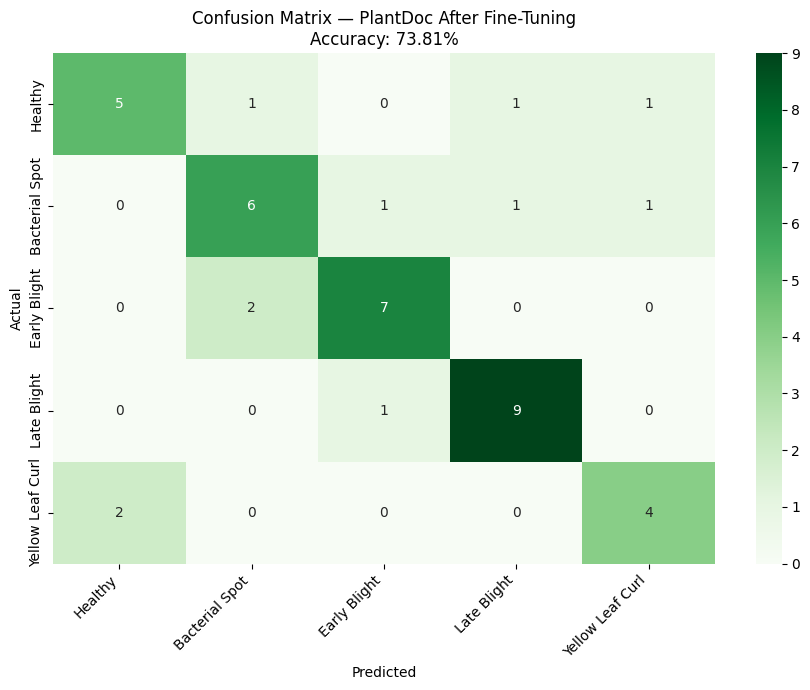


Fine-Tuned Classification Report:
                  precision    recall  f1-score   support

         Healthy       0.71      0.62      0.67         8
  Bacterial Spot       0.67      0.67      0.67         9
    Early Blight       0.78      0.78      0.78         9
     Late Blight       0.82      0.90      0.86        10
Yellow Leaf Curl       0.67      0.67      0.67         6

        accuracy                           0.74        42
       macro avg       0.73      0.73      0.73        42
    weighted avg       0.74      0.74      0.74        42



In [ ]:
cm_ft = confusion_matrix(ft_labels_list, ft_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Greens',
            xticklabels=short_names, yticklabels=short_names)
plt.title(f'Confusion Matrix — PlantDoc After Fine-Tuning\nAccuracy: {ft_accuracy:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'plantdoc_finetuned_confusion_matrix.png'), dpi=150)
plt.show()

print("\nFine-Tuned Classification Report:")
print(classification_report(ft_labels_list, ft_preds, target_names=short_names))

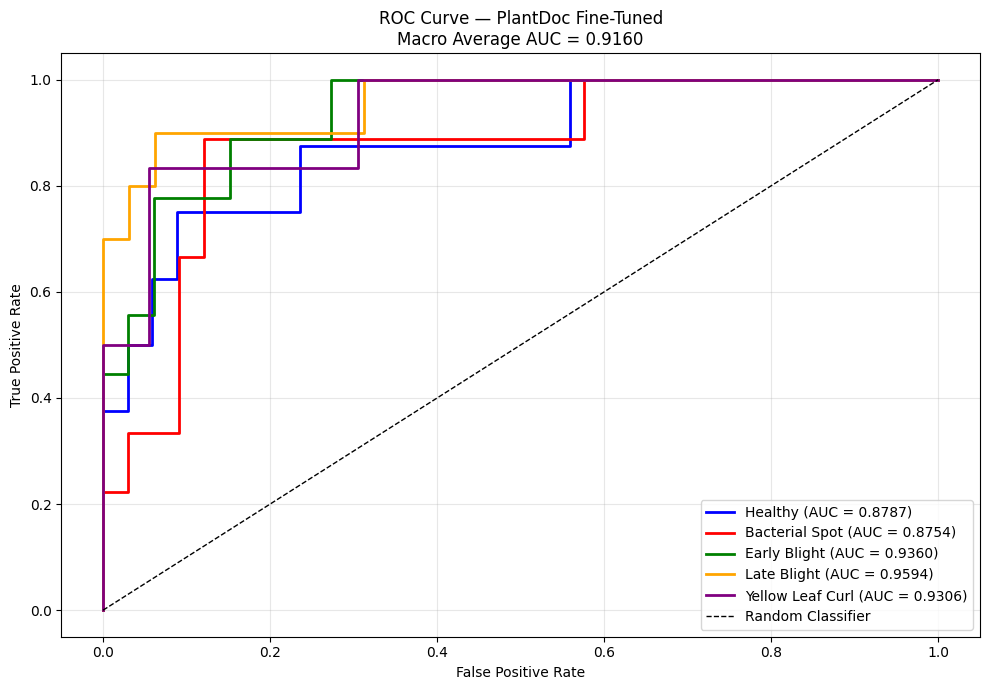


Fine-Tuned AUC per class:
  Healthy                  : 0.8787
  Bacterial Spot           : 0.8754
  Early Blight             : 0.9360
  Late Blight              : 0.9594
  Yellow Leaf Curl         : 0.9306

  Macro Average AUC : 0.9160


In [ ]:
ft_labels_bin = label_binarize(ft_labels_list, classes=list(range(CONFIG['num_classes'])))

plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange', 'purple']
ft_auc_scores = {}

for i, (name, color) in enumerate(zip(short_names, colors)):
    fpr, tpr, _ = roc_curve(ft_labels_bin[:, i], ft_probs[:, i])
    auc_val      = auc(fpr, tpr)
    ft_auc_scores[name] = auc_val
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc_val:.4f})')

ft_macro_auc = np.mean(list(ft_auc_scores.values()))
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.title(f'ROC Curve — PlantDoc Fine-Tuned\nMacro Average AUC = {ft_macro_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'plantdoc_finetuned_roc_curve.png'), dpi=150)
plt.show()

print("\nFine-Tuned AUC per class:")
for name, score in ft_auc_scores.items():
    print(f"  {name:25s}: {score:.4f}")
print(f"\n  Macro Average AUC : {ft_macro_auc:.4f}")

In [ ]:
print("=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print(f"{'Metric':<30} {'PlantVillage':>12} {'PlantDoc FT':>12}")
print("-" * 50)
print(f"{'Overall Accuracy':<30} {'99%':>12} {ft_accuracy:>11.2f}%")
print(f"{'Macro AUC':<30} {'0.9900':>12} {ft_macro_auc:>12.4f}")
print("=" * 50)

print("\nPer-class AUC:")
print(f"{'Class':<25} {'PlantVillage':>12} {'PlantDoc FT':>12}")
print("-" * 50)
for name in short_names:
    ft = ft_auc_scores.get(name, 0)
    print(f"{name:<25} {'~0.99':>12} {ft:>12.4f}")

# Save summary
summary = {
    'plantvillage_accuracy'           : 99.0,
    'plantdoc_finetuned_accuracy'     : ft_accuracy,
    'plantdoc_finetuned_macro_auc'    : ft_macro_auc,
    'plantdoc_finetuned_auc_per_class': ft_auc_scores,
}

with open(os.path.join(RESULTS, 'final_results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("\nFinal summary saved to Drive!")

RESULTS SUMMARY
Metric                         PlantVillage  PlantDoc FT
--------------------------------------------------
Overall Accuracy                        99%       73.81%
Macro AUC                            0.9900       0.9160

Per-class AUC:
Class                     PlantVillage  PlantDoc FT
--------------------------------------------------
Healthy                          ~0.99       0.8787
Bacterial Spot                   ~0.99       0.8754
Early Blight                     ~0.99       0.9360
Late Blight                      ~0.99       0.9594
Yellow Leaf Curl                 ~0.99       0.9306

Final summary saved to Drive!


In [ ]:
print("PlantDoc train class counts:")
for idx, name in enumerate(short_names):
    count = pd_train_labels.count(idx)
    print(f"  {name}: {count}")

PlantDoc train class counts:


NameError: name 'pd_train_labels' is not defined

In [ ]:
##
#binary
##


In [ ]:
# Binary classification by collapsing 5-class predictions
# Healthy = 0, everything else = Diseased = 1

import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

# Load best model
checkpoint = torch.load(
    os.path.join(MODELS, 'best_hybrid_v2.pth'),
    map_location=device
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

HEALTHY_IDX = class_to_idx['Tomato_healthy']

all_preds_5class, all_labels_5class, all_probs_5class = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds_5class.extend(preds)
        all_labels_5class.extend(labels.numpy())
        all_probs_5class.extend(probs)

all_preds_5class  = np.array(all_preds_5class)
all_labels_5class = np.array(all_labels_5class)
all_probs_5class  = np.array(all_probs_5class)

# Collapse to binary — Healthy = 0, Diseased = 1
binary_true  = (all_labels_5class != HEALTHY_IDX).astype(int)
binary_pred  = (all_preds_5class  != HEALTHY_IDX).astype(int)

# Binary probability = 1 - P(healthy) = P(diseased)
binary_prob_diseased = 1 - all_probs_5class[:, HEALTHY_IDX]

binary_names = ['Healthy', 'Diseased']

print(f"Binary Accuracy: {accuracy_score(binary_true, binary_pred)*100:.2f}%")

Binary Accuracy: 99.50%


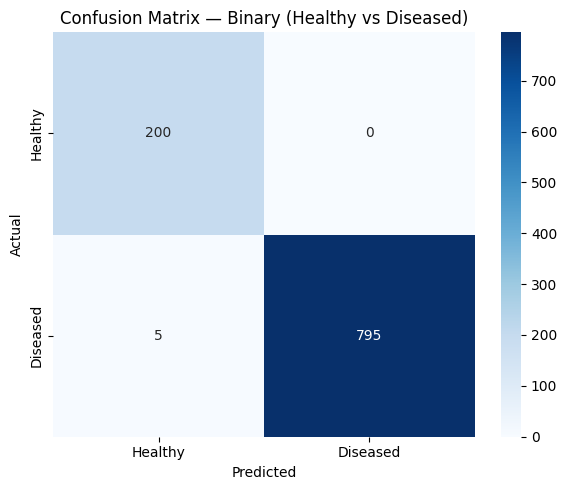


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      1.00      0.99       200
    Diseased       1.00      0.99      1.00       800

    accuracy                           0.99      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      0.99      1.00      1000



In [ ]:
cm_binary = confusion_matrix(binary_true, binary_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=binary_names, yticklabels=binary_names)
plt.title('Confusion Matrix — Binary (Healthy vs Diseased)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'binary_from_5class_confusion_matrix.png'), dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(binary_true, binary_pred, target_names=binary_names))

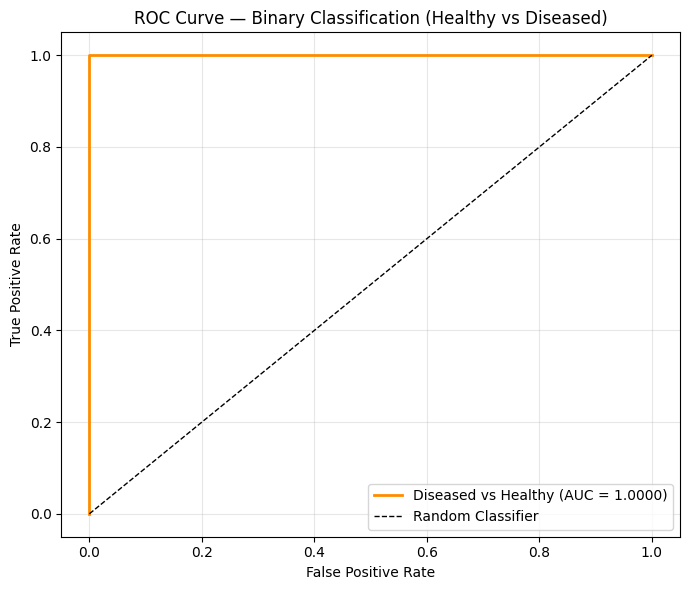

Binary AUC: 1.0000


In [ ]:
fpr, tpr, _ = roc_curve(binary_true, binary_prob_diseased)
binary_auc  = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Diseased vs Healthy (AUC = {binary_auc:.4f})')
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.title('ROC Curve — Binary Classification (Healthy vs Diseased)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'binary_roc_curve.png'), dpi=150)
plt.show()

print(f"Binary AUC: {binary_auc:.4f}")

In [ ]:
binary_summary = {
    'binary_accuracy' : accuracy_score(binary_true, binary_pred) * 100,
    'binary_auc'      : binary_auc,
    'confusion_matrix': cm_binary.tolist(),
}

import json
with open(os.path.join(RESULTS, 'binary_results_summary.json'), 'w') as f:
    json.dump(binary_summary, f, indent=2)

print("Binary results saved!")
print(json.dumps(binary_summary, indent=2))

Binary results saved!
{
  "binary_accuracy": 99.5,
  "binary_auc": 1.0,
  "confusion_matrix": [
    [
      200,
      0
    ],
    [
      5,
      795
    ]
  ]
}


In [ ]:
#
#
#
# New Mendeley Tomato Dataset
#
#
#
#

In [17]:
TOMATO_DATASET = '/content/drive/MyDrive/project/data/TomatoDataset'

TOMATO_MAPPING = {
    'Tomato_healthy'                       : class_to_idx['Tomato_healthy'],
    'Tomato_Bacterial_spot'                : class_to_idx['Tomato_Bacterial_spot'],
    'Tomato_Early_blight'                  : class_to_idx['Tomato_Early_blight'],
    'Tomato_Late_blight'                   : class_to_idx['Tomato_Late_blight'],
    'Tomato__Tomato_YellowLeaf_Curl_Virus': class_to_idx['Tomato__Tomato_YellowLeaf__Curl_Virus'],
}

print("Dataset mapping:")
for folder, idx in TOMATO_MAPPING.items():
    print(f"  {folder} → {idx}: {idx_to_class[idx]}")

Dataset mapping:
  Tomato_healthy → 0: Tomato_healthy
  Tomato_Bacterial_spot → 1: Tomato_Bacterial_spot
  Tomato_Early_blight → 2: Tomato_Early_blight
  Tomato_Late_blight → 3: Tomato_Late_blight
  Tomato__Tomato_YellowLeaf_Curl_Virus → 4: Tomato__Tomato_YellowLeaf__Curl_Virus


In [18]:
tomato_paths, tomato_labels = [], []

for folder_name, label_idx in TOMATO_MAPPING.items():
    folder_path = os.path.join(TOMATO_DATASET, folder_name)
    if not os.path.exists(folder_path):
        print(f"WARNING: not found — {folder_path}")
        continue
    for img_file in os.listdir(folder_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            tomato_paths.append(os.path.join(folder_path, img_file))
            tomato_labels.append(label_idx)

print(f"Total images loaded: {len(tomato_paths)}")
print("\nClass breakdown:")
for idx, name in enumerate(short_names):
    print(f"  {name}: {tomato_labels.count(idx)}")

Total images loaded: 13482

Class breakdown:
  Healthy: 3052
  Bacterial Spot: 2826
  Early Blight: 2455
  Late Blight: 3113
  Yellow Leaf Curl: 2036


In [19]:
tomato_dataset = TomatoDataset(tomato_paths, tomato_labels, val_test_transform)
tomato_loader  = DataLoader(
    tomato_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"Total batches : {len(tomato_loader)}")
print(f"Total images  : {len(tomato_dataset)}")

Total batches : 422
Total images  : 13482


In [ ]:
checkpoint = torch.load(
    os.path.join(MODELS, 'best_hybrid_v2.pth'),
    map_location=device
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

td_preds, td_labels_list, td_probs = [], [], []

with torch.no_grad():
    for images, labels in tomato_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(dim=1).cpu().numpy()
        td_preds.extend(preds)
        td_labels_list.extend(labels.numpy())
        td_probs.extend(probs)

td_preds       = np.array(td_preds)
td_labels_list = np.array(td_labels_list)
td_probs       = np.array(td_probs)

td_accuracy = (td_preds == td_labels_list).mean() * 100
print(f"TomatoDataset Overall Accuracy: {td_accuracy:.2f}%")

In [ ]:
cm_td = confusion_matrix(td_labels_list, td_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_td, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.title(f'Confusion Matrix — TomatoDataset\nAccuracy: {td_accuracy:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'tomatodataset_confusion_matrix.png'), dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(td_labels_list, td_preds, target_names=short_names))

In [ ]:
td_labels_bin = label_binarize(td_labels_list, classes=list(range(CONFIG['num_classes'])))

plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange', 'purple']
td_auc_scores = {}

for i, (name, color) in enumerate(zip(short_names, colors)):
    fpr, tpr, _ = roc_curve(td_labels_bin[:, i], td_probs[:, i])
    auc_val      = auc(fpr, tpr)
    td_auc_scores[name] = auc_val
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc_val:.4f})')

td_macro_auc = np.mean(list(td_auc_scores.values()))
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.title(f'ROC Curve — TomatoDataset\nMacro Average AUC = {td_macro_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'tomatodataset_roc_curve.png'), dpi=150)
plt.show()

print("\nAUC per class:")
for name, score in td_auc_scores.items():
    print(f"  {name:25s}: {score:.4f}")
print(f"\n  Macro Average AUC : {td_macro_auc:.4f}")

In [ ]:
print("=" * 55)
print("RESULTS — TomatoDataset Evaluation")
print("=" * 55)
print(f"Overall Accuracy  : {td_accuracy:.2f}%")
print(f"Macro Average AUC : {td_macro_auc:.4f}")
print("\nPer-class AUC:")
for name, score in td_auc_scores.items():
    print(f"  {name:25s}: {score:.4f}")

# Save summary
td_summary = {
    'accuracy'        : td_accuracy,
    'macro_auc'       : td_macro_auc,
    'auc_per_class'   : td_auc_scores,
}
with open(os.path.join(RESULTS, 'tomatodataset_results.json'), 'w') as f:
    json.dump(td_summary, f, indent=2)

print("\nSaved to Drive!")

In [ ]:
##Finetuning

In [ ]:
print("TomatoDataset class breakdown:")
for idx, name in enumerate(short_names):
    count = tomato_labels.count(idx)
    print(f"  {name}: {count}")
print(f"Total: {len(tomato_paths)}")

TomatoDataset class breakdown:
  Healthy: 157
  Bacterial Spot: 108
  Early Blight: 298
  Late Blight: 111
  Yellow Leaf Curl: 100
Total: 774


In [ ]:
from sklearn.model_selection import train_test_split

td_train_paths, td_test_paths, td_train_labels, td_test_labels = train_test_split(
    tomato_paths, tomato_labels,
    test_size=0.20,
    stratify=tomato_labels,
    random_state=CONFIG['seed']
)

print(f"Fine-tune Train : {len(td_train_paths)}")
print(f"Fine-tune Test  : {len(td_test_paths)}")
print("\nTrain class breakdown:")
for idx, name in enumerate(short_names):
    print(f"  {name}: {td_train_labels.count(idx)}")
print("\nTest class breakdown:")
for idx, name in enumerate(short_names):
    print(f"  {name}: {td_test_labels.count(idx)}")

Fine-tune Train : 619
Fine-tune Test  : 155

Train class breakdown:
  Healthy: 126
  Bacterial Spot: 86
  Early Blight: 238
  Late Blight: 89
  Yellow Leaf Curl: 80

Test class breakdown:
  Healthy: 31
  Bacterial Spot: 22
  Early Blight: 60
  Late Blight: 22
  Yellow Leaf Curl: 20


In [ ]:
from collections import Counter

# Augmentation for fine-tune training
td_train_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.5),
    A.RandomResizedCrop(
        size=(CONFIG['image_size'], CONFIG['image_size']),
        scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5
    ),
    A.ColorJitter(brightness=0.3, contrast=0.3,
                  saturation=0.2, hue=0.1, p=0.5),
    A.RandomShadow(p=0.3),
    A.CoarseDropout(max_holes=8, max_height=20,
                    max_width=20, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

td_train_dataset = TomatoDataset(td_train_paths, td_train_labels, td_train_transform)
td_test_dataset  = TomatoDataset(td_test_paths,  td_test_labels,  val_test_transform)

# Weighted sampler for class imbalance
td_class_counts   = Counter(td_train_labels)
td_class_weights  = {cls: 1.0/count for cls, count in td_class_counts.items()}
td_sample_weights = torch.tensor(
    [td_class_weights[l] for l in td_train_labels], dtype=torch.float
)
td_sampler = WeightedRandomSampler(
    td_sample_weights, len(td_sample_weights), replacement=True
)

td_train_loader = DataLoader(td_train_dataset, batch_size=8,
                             sampler=td_sampler, num_workers=2,
                             pin_memory=True)
td_test_loader  = DataLoader(td_test_dataset,  batch_size=8,
                             shuffle=False, num_workers=2,
                             pin_memory=True)

print(f"Train batches : {len(td_train_loader)}")
print(f"Test batches  : {len(td_test_loader)}")

Train batches : 78
Test batches  : 20


/tmp/ipykernel_661/3084133114.py:16: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20,
/tmp/ipykernel_661/3084133114.py:18: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


In [ ]:
checkpoint = torch.load(
    os.path.join(MODELS, 'best_hybrid_v2.pth'),
    map_location=device
)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Base model loaded — PlantVillage Val Acc: {checkpoint['val_acc']:.2f}%")

# Unfreeze everything
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"All params unfrozen: {trainable:,}")

Base model loaded — PlantVillage Val Acc: 99.10%
All params unfrozen: 23,829,878


In [ ]:
# Different lr per branch
td_optimizer = optim.Adam([
    {'params': model.cnn_branch.parameters(),   'lr': 1e-5},
    {'params': model.fusion.parameters(),        'lr': 1e-5},
    {'params': model.classifier.parameters(),    'lr': 1e-5},
    {'params': model.trans_branch.parameters(),  'lr': 1e-6},
], lr=1e-5)

td_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    td_optimizer, T_max=20, eta_min=1e-7
)

# Weighted loss
td_counts   = [td_class_counts.get(i, 1) for i in range(CONFIG['num_classes'])]
td_weights  = torch.tensor([1.0/c for c in td_counts],
                            dtype=torch.float).to(device)
td_criterion = nn.CrossEntropyLoss(weight=td_weights)

best_td_acc = 0.0
FT_EPOCHS   = 55

print(f"Fine-tuning for {FT_EPOCHS} epochs...")
print("=" * 65)

for epoch in range(FT_EPOCHS):
    # Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in td_train_loader:
        images, labels = images.to(device), labels.to(device)
        td_optimizer.zero_grad()
        outputs = model(images)
        loss    = td_criterion(outputs, labels)
        loss.backward()
        td_optimizer.step()
        running_loss += loss.item()
        correct      += (outputs.argmax(dim=1) == labels).sum().item()
        total        += labels.size(0)

    avg_loss  = running_loss / len(td_train_loader)
    train_acc = correct / total * 100

    # Test
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in td_test_loader:
            images, labels = images.to(device), labels.to(device)
            preds   = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    test_acc = correct / total * 100
    td_scheduler.step()

    if test_acc > best_td_acc:
        best_td_acc = test_acc
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'val_acc'          : test_acc,
            'class_to_idx'     : class_to_idx,
            'config'           : CONFIG,
        }, os.path.join(MODELS, 'best_hybrid_v2_tomato_finetuned.pth'))

    print(f"Epoch {epoch+1:02d}/{FT_EPOCHS} | "
          f"Train Loss: {avg_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}% | "
          f"Best: {best_td_acc:.2f}%")

print(f"\nFine-tuning complete. Best Acc: {best_td_acc:.2f}%")

Fine-tuning for 55 epochs...
Epoch 01/55 | Train Loss: 1.7018 | Train Acc: 55.74% | Test Acc: 53.55% | Best: 53.55%
Epoch 02/55 | Train Loss: 1.7260 | Train Acc: 53.63% | Test Acc: 53.55% | Best: 53.55%
Epoch 03/55 | Train Loss: 1.3743 | Train Acc: 60.10% | Test Acc: 55.48% | Best: 55.48%
Epoch 04/55 | Train Loss: 1.3780 | Train Acc: 56.87% | Test Acc: 55.48% | Best: 55.48%
Epoch 05/55 | Train Loss: 1.3271 | Train Acc: 58.32% | Test Acc: 60.65% | Best: 60.65%
Epoch 06/55 | Train Loss: 1.2005 | Train Acc: 62.04% | Test Acc: 60.65% | Best: 60.65%
Epoch 07/55 | Train Loss: 1.2850 | Train Acc: 60.26% | Test Acc: 60.00% | Best: 60.65%
Epoch 08/55 | Train Loss: 1.0721 | Train Acc: 62.04% | Test Acc: 60.65% | Best: 60.65%
Epoch 09/55 | Train Loss: 0.9931 | Train Acc: 62.84% | Test Acc: 60.00% | Best: 60.65%
Epoch 10/55 | Train Loss: 1.2092 | Train Acc: 60.74% | Test Acc: 60.00% | Best: 60.65%
Epoch 11/55 | Train Loss: 0.9635 | Train Acc: 67.69% | Test Acc: 61.94% | Best: 61.94%
Epoch 12/55 | 

Fine-tuned TomatoDataset Accuracy: 71.61%


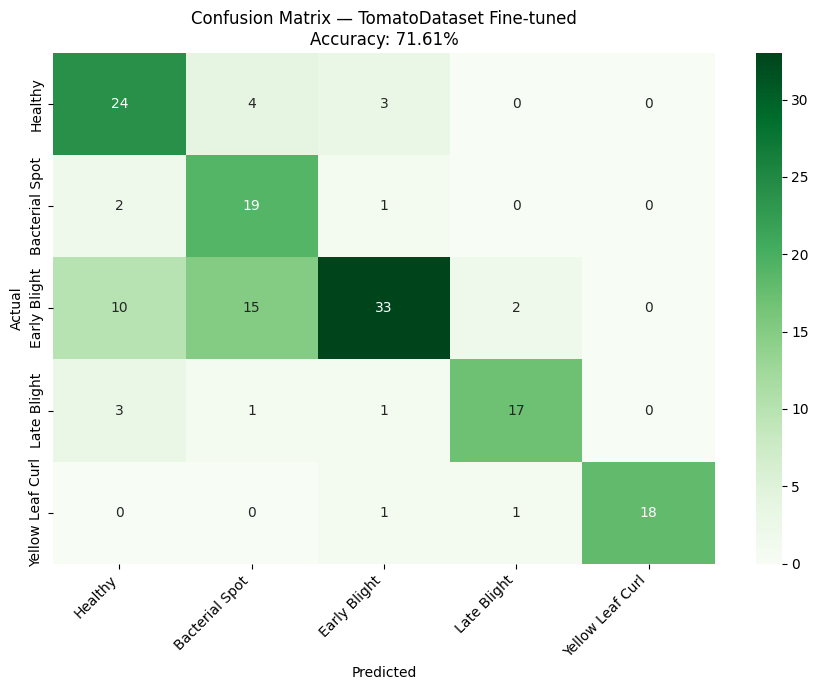


Classification Report:
                  precision    recall  f1-score   support

         Healthy       0.62      0.77      0.69        31
  Bacterial Spot       0.49      0.86      0.62        22
    Early Blight       0.85      0.55      0.67        60
     Late Blight       0.85      0.77      0.81        22
Yellow Leaf Curl       1.00      0.90      0.95        20

        accuracy                           0.72       155
       macro avg       0.76      0.77      0.75       155
    weighted avg       0.77      0.72      0.72       155



In [ ]:
checkpoint_td = torch.load(
    os.path.join(MODELS, 'best_hybrid_v2_tomato_finetuned.pth'),
    map_location=device
)
model.load_state_dict(checkpoint_td['model_state_dict'])
model.eval()

td_ft_preds, td_ft_labels, td_ft_probs = [], [], []

with torch.no_grad():
    for images, labels in td_test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(dim=1).cpu().numpy()
        td_ft_preds.extend(preds)
        td_ft_labels.extend(labels.numpy())
        td_ft_probs.extend(probs)

td_ft_preds  = np.array(td_ft_preds)
td_ft_labels = np.array(td_ft_labels)
td_ft_probs  = np.array(td_ft_probs)

td_ft_acc = (td_ft_preds == td_ft_labels).mean() * 100
print(f"Fine-tuned TomatoDataset Accuracy: {td_ft_acc:.2f}%")

# Confusion matrix
cm_td_ft = confusion_matrix(td_ft_labels, td_ft_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_td_ft, annot=True, fmt='d', cmap='Greens',
            xticklabels=short_names, yticklabels=short_names)
plt.title(f'Confusion Matrix — TomatoDataset Fine-tuned\nAccuracy: {td_ft_acc:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'tomato_finetuned_confusion_matrix.png'), dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(td_ft_labels, td_ft_preds, target_names=short_names))

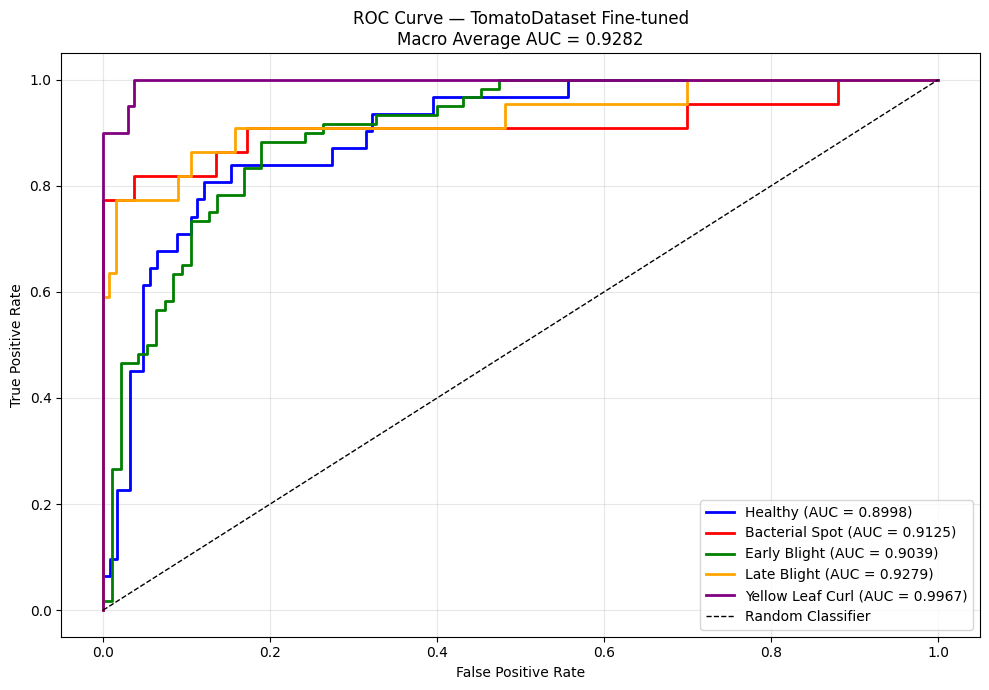


AUC per class:
  Healthy                  : 0.8998
  Bacterial Spot           : 0.9125
  Early Blight             : 0.9039
  Late Blight              : 0.9279
  Yellow Leaf Curl         : 0.9967

  Macro Average AUC : 0.9282


In [ ]:
td_ft_labels_bin = label_binarize(td_ft_labels,
                                   classes=list(range(CONFIG['num_classes'])))

plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange', 'purple']
td_ft_auc_scores = {}

for i, (name, color) in enumerate(zip(short_names, colors)):
    fpr, tpr, _ = roc_curve(td_ft_labels_bin[:, i], td_ft_probs[:, i])
    auc_val      = auc(fpr, tpr)
    td_ft_auc_scores[name] = auc_val
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc_val:.4f})')

td_ft_macro_auc = np.mean(list(td_ft_auc_scores.values()))
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.title(f'ROC Curve — TomatoDataset Fine-tuned\n'
          f'Macro Average AUC = {td_ft_macro_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'tomato_finetuned_roc_curve.png'), dpi=150)
plt.show()

print("\nAUC per class:")
for name, score in td_ft_auc_scores.items():
    print(f"  {name:25s}: {score:.4f}")
print(f"\n  Macro Average AUC : {td_ft_macro_auc:.4f}")